# Evaluation of Low-Pass Filter RNN
## Model loading

In [288]:
from model import LowpassRNN
import torch
from pathlib import Path
import numpy as np
import os

In [289]:
hidden_size = 32
num_layers = 2
buffer_size = 96
sample_rate = 48000
checkpoint_folder = "checkpoints-6"
dataset_folder = "dataset-6"
dataset_size = 1114

In [290]:
state = torch.load(
    os.path.join(checkpoint_folder, Path(r"best.pt")),
)
filter_rnn = LowpassRNN(hidden_size, num_layers)
filter_rnn.load_state_dict(state["model_state_dict"])
filter_rnn.eval()

LowpassRNN(
  (gru): GRU(2, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

### Test model with known data

In [291]:
def run_inference(
    model: LowpassRNN,
    input: np.ndarray,
    fc_norm: float,
    buffer_size: int,
    sample_rate: int,
) -> np.ndarray:
    """
    Args:
        model:       trained LowpassRNN
        input:       raw audio signal of length N, where N is a multiple of buffer_size
        cutoff_freq: cutoff frequency in Hz
        buffer_size: must match the buffer_size used during training
        sample_rate: must match the sample_rate used during training
    Returns:
        filtered signal of length N
    """
    model.eval()  # disable dropout etc. if any

    # fc_norm = (2 * cutoff_freq) / sample_rate
    n_buffers = len(input) // buffer_size
    output_buffers = []
    hidden = None

    with torch.no_grad():  # disable gradient tracking, saves memory and speeds up inference
        for i in range(n_buffers):
            buffer = input[i * buffer_size : (i + 1) * buffer_size]
            x = torch.from_numpy(buffer).float()          # (buffer_size,) — zero copy
            # shape: (1, buffer_size, 2) — batch size of 1
            fc_channel = torch.full((buffer_size,), fc_norm)
            x = torch.stack([x, fc_channel], dim=-1).unsqueeze(0)  # (1, buffer_size, 2)

            output, hidden = model(x, hidden)
            # output shape: (1, buffer_size, 1) → flatten to (buffer_size,)
            output_buffers.append(output.squeeze().numpy())

    return np.concatenate(output_buffers)  # shape: (N,)

In [292]:
from random import randint

data_idx = randint(0, dataset_size)
x = np.load(os.path.join(dataset_folder, "inputs/input-{}.npy".format(data_idx)))
y = np.load(os.path.join(dataset_folder, "expected/expected-{}.npy".format(data_idx)))
print("Sample {}".format(data_idx))

y_pred = run_inference(
    filter_rnn, x[:-1], fc_norm=x[-1], buffer_size=buffer_size, sample_rate=sample_rate
)

Sample 992


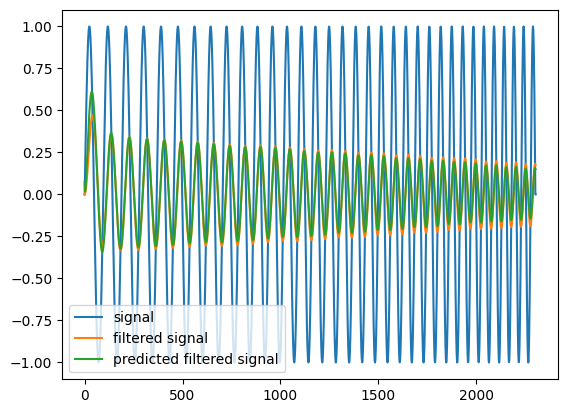

In [293]:
import matplotlib.pyplot as plt

t = np.arange(len(y))
plt.figure()
plt.plot(t, x[:-1], label="signal")
plt.plot(t, y, label="filtered signal")
plt.plot(t, y_pred, label="predicted filtered signal")
plt.legend(loc="lower left")
plt.show()

### Test model with unknown data

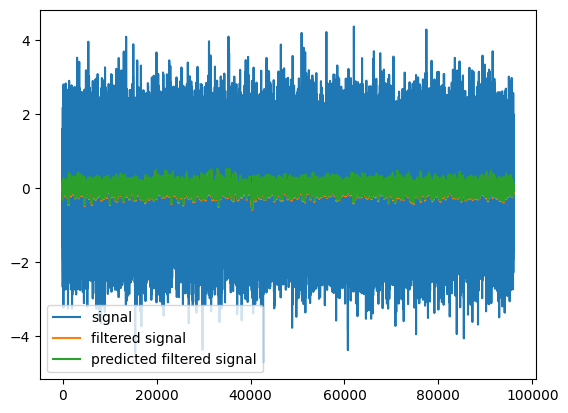

In [ ]:
from create_dataset import lowpass_filter
import colorednoise as cn

cutoff_freq = 250 # Hz
length = 2 # seconds

buffer_amount_in_length = (length * sample_rate) // buffer_size
N = buffer_amount_in_length * buffer_size
beta = 0  # the exponent: 0=white noite; 1=pink noise;  2=red noise (also "brownian noise")

brown_noise = cn.powerlaw_psd_gaussian(beta, N)
filtered_noise = lowpass_filter(brown_noise, cutoff_freq, sample_rate)

fc_norm = np.log2(2 * cutoff_freq / sample_rate)

pred = run_inference(filter_rnn, brown_noise, fc_norm, buffer_size, sample_rate)

t = np.arange(len(pred))
plt.figure()
plt.plot(t, brown_noise, label="signal")
plt.plot(t, filtered_noise, label="filtered signal")
plt.plot(t, pred, label="predicted filtered signal")
plt.legend(loc="lower left")
plt.show()

In [295]:
from create_dataset import generate_log_sweep, cut_to_nearest_multiple

cutoff_freq = 50  # Hz
length = 2  # seconds

sweeps, fsweeps = generate_log_sweep(sample_rate, 20, 7500, 1.1, cutoff_freq)

print(len(sweeps))

fc_norm = 2 * cutoff_freq / sample_rate

sweeps = cut_to_nearest_multiple(sweeps, buffer_size)
fsweeps = cut_to_nearest_multiple(fsweeps, buffer_size)
pred_fsweeps = run_inference(filter_rnn, sweeps, fc_norm, buffer_size, sample_rate)

t = np.arange(len(pred_fsweeps))

26308


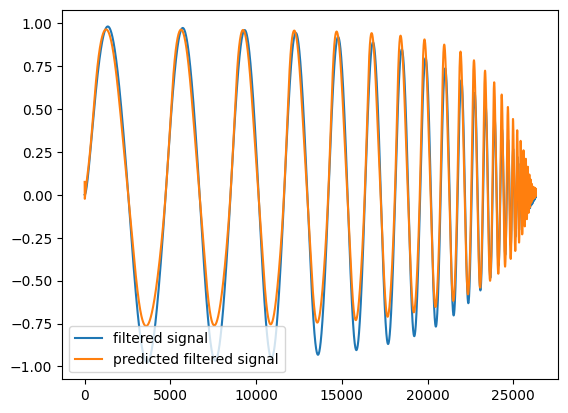

In [296]:
plt.figure()
# plt.plot(t, sweeps, label="signal")
plt.plot(t, fsweeps, label="filtered signal")
plt.plot(t, pred_fsweeps, label="predicted filtered signal")
plt.legend(loc="lower left")
plt.show()

Interestingly enough, the RNN model seems to have a steeper slope than the filter it learned from for lower cutoff frequencies.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def plot_bode(
    model: LowpassRNN,
    cutoff_freq: float,
    buffer_size: int,
    sample_rate: int,
    n_buffers: int = 32,  # more buffers = better frequency resolution at low freqs
):
    model.eval()
    fc_norm = np.log2(2 * cutoff_freq / sample_rate)

    # Build impulse signal: 1 at sample 0, 0 everywhere else
    impulse = np.zeros(n_buffers * buffer_size)
    impulse[0] = 1.0

    # Run inference
    hidden = None
    output_buffers = []

    with torch.no_grad():
        for i in range(n_buffers):
            buffer = impulse[i * buffer_size : (i + 1) * buffer_size]
            x = torch.from_numpy(buffer).float()
            fc_channel = torch.full((buffer_size,), fc_norm)
            x = torch.stack([x, fc_channel], dim=-1).unsqueeze(0)  # (1, buffer_size, 2)
            output, hidden = model(x, hidden)
            output_buffers.append(output.squeeze().numpy())

    impulse_response = np.concatenate(output_buffers)  # (n_buffers * buffer_size,)

    # FFT of impulse response = frequency response
    N = len(impulse_response)
    freq_response = np.fft.rfft(impulse_response, n=N)
    magnitude_db = 20 * np.log10(np.abs(freq_response) + 1e-8)  # +1e-8 to avoid log(0)
    freqs = np.fft.rfftfreq(N, d=1.0 / sample_rate)

    # Also compute reference butterworth response for comparison
    from scipy.signal import freqz, butter

    b, a = butter(1, cutoff_freq / (sample_rate / 2), btype="low", analog=False)
    w, h = freqz(b, a, worN=N // 2 + 1, fs=sample_rate)
    reference_db = 20 * np.log10(np.abs(h) + 1e-8)

    plt.figure(figsize=(10, 5))
    plt.semilogx(freqs[1:], magnitude_db[1:], label="RNN filter")  # skip DC bin
    plt.semilogx(w[1:], reference_db[1:], "--", label="Reference Butterworth")
    plt.axvline(cutoff_freq, color="r", linestyle=":", label=f"fc = {cutoff_freq} Hz")
    plt.axhline(-3, color="gray", linestyle=":", label="-3 dB")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(f"Bode Magnitude Plot — fc = {cutoff_freq} Hz")
    plt.legend()
    plt.grid(True, which="both")
    plt.ylim(-60, max(5, max(magnitude_db[1:])+1))
    plt.tight_layout()
    plt.show()

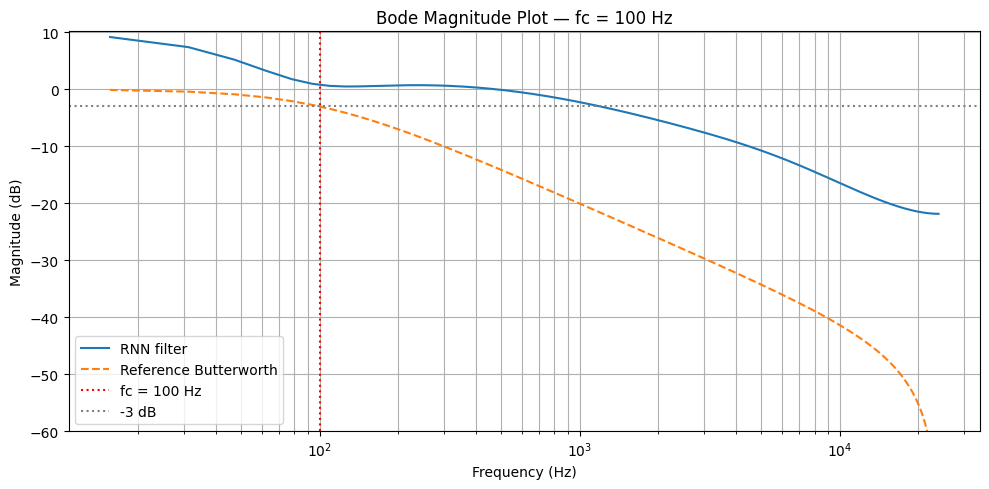

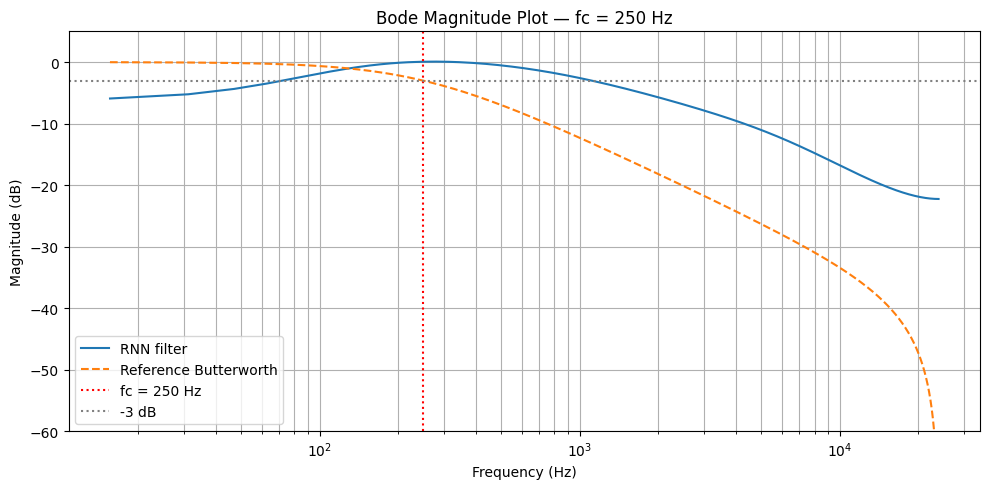

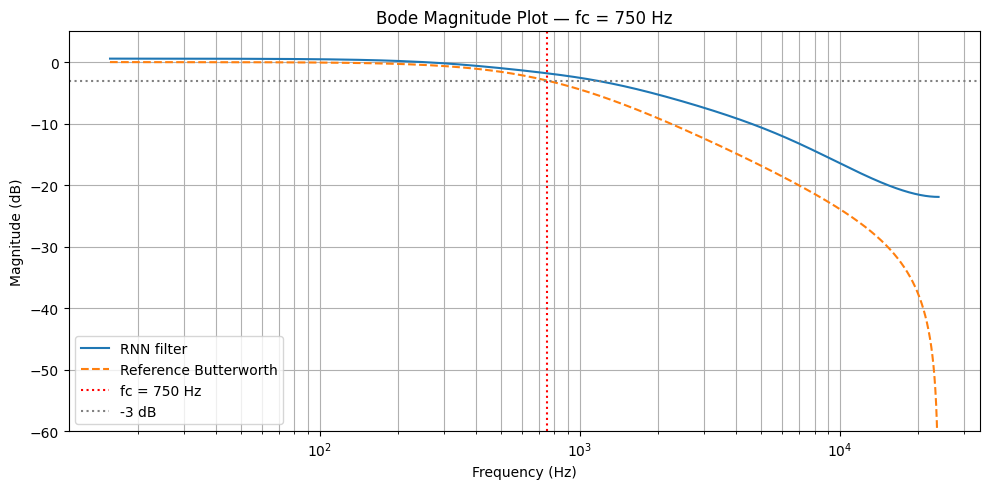

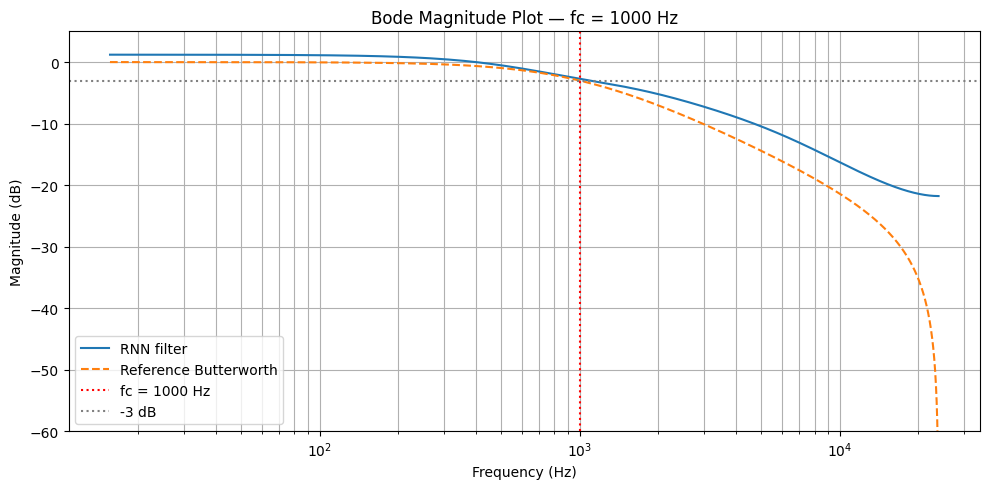

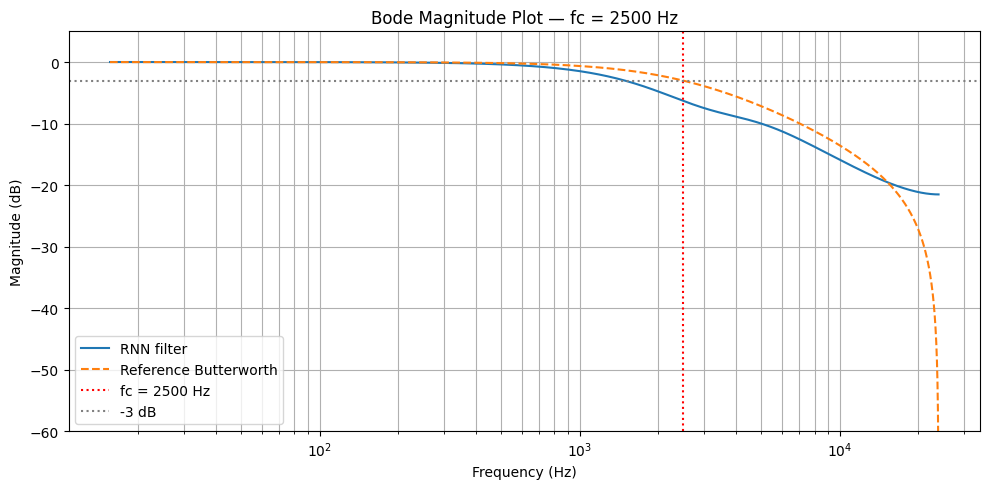

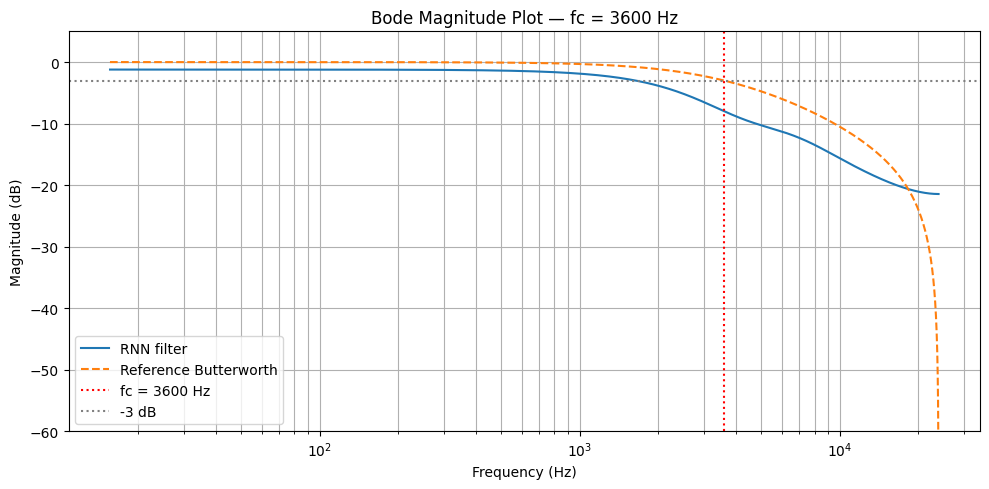

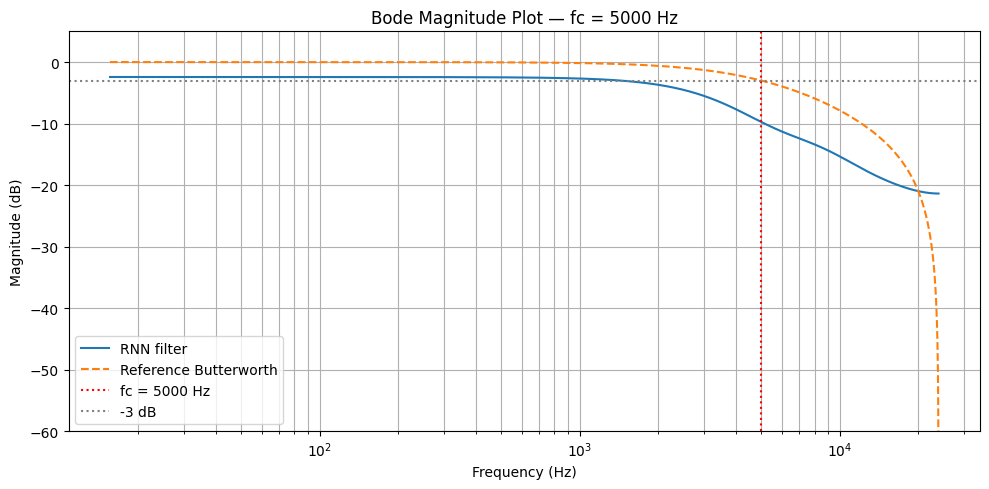

In [298]:
for fc in [100, 250, 750, 1000, 2500, 3600, 5000]:
    plot_bode(filter_rnn, fc, buffer_size, sample_rate)